===== 小波压缩数据对比 =====
原始图像数据量：0.2500 MB
压缩后数据量：0.0655 MB
压缩比：3.8:1
数据量减少：73.8%


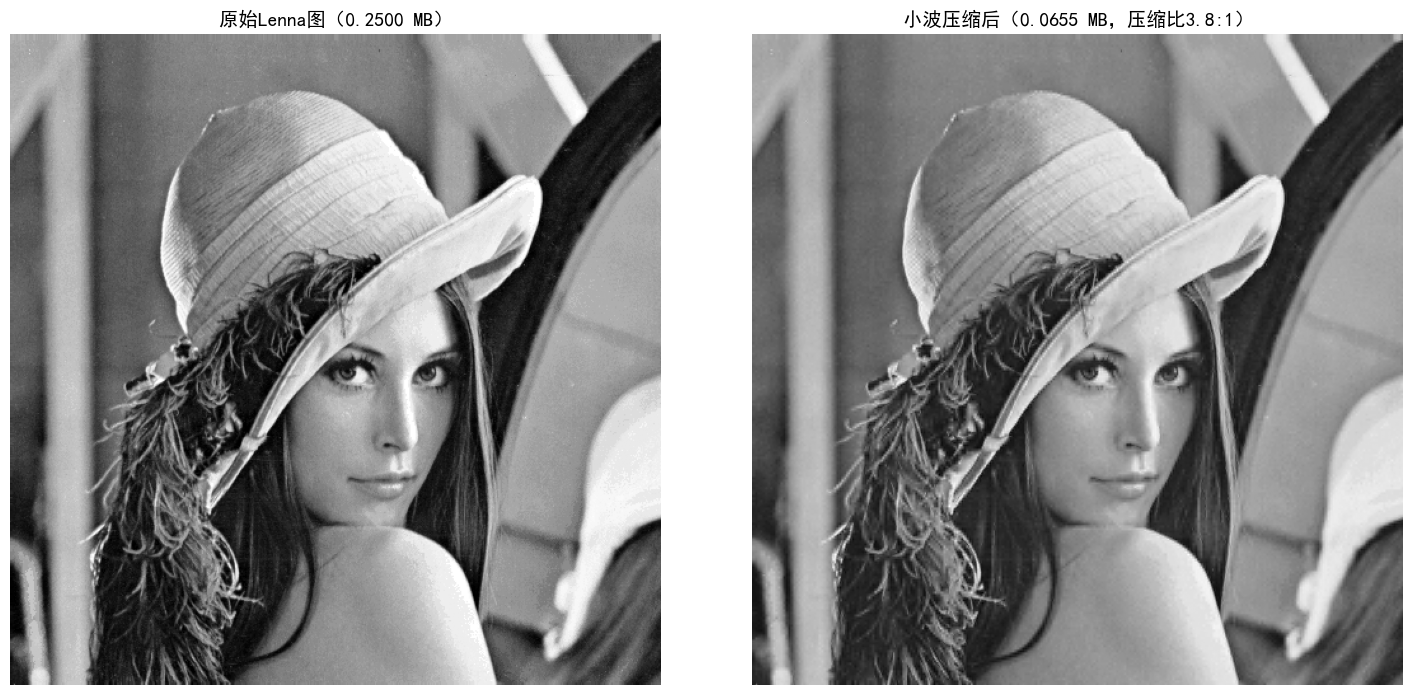

In [2]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取图像
img = cv2.imread('lenna.jpg', 0)
if img is None:
    raise ValueError("未找到lenna.jpg！请确认图片路径正确")

# 计算原始数据量（字节）
h, w = img.shape
original_size = h * w * 1  # 灰度图1字节/像素
original_size_mb = original_size / 1024 / 1024  # 转换为MB

# 小波压缩核心函数
def wavelet_compress(img, wavelet='db2', level=1, k=2):
    # 小波分解
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    LL, (LH, HL, HH) = coeffs

    # 计算阈值
    threshold = k * np.mean(np.abs(LH) + np.abs(HL) + np.abs(HH))

    # 高频系数阈值量化
    LH_q = np.where(np.abs(LH) > threshold, LH, 0)
    HL_q = np.where(np.abs(HL) > threshold, HL, 0)
    HH_q = np.where(np.abs(HH) > threshold, HH, 0)

    # 计算压缩后非零系数数量 & 压缩后数据量（仅存储非零系数，模拟实际存储）
    non_zero_LL = np.count_nonzero(LL)
    non_zero_LH = np.count_nonzero(LH_q)
    non_zero_HL = np.count_nonzero(HL_q)
    non_zero_HH = np.count_nonzero(HH_q)
    total_non_zero = non_zero_LL + non_zero_LH + non_zero_HL + non_zero_HH
    compress_size = total_non_zero * 1  # 非零系数1字节/个
    compress_size_mb = compress_size / 1024 / 1024

    # 计算压缩比
    compress_ratio = original_size / total_non_zero

    # 逆变换解压
    coeffs_q = (LL, (LH_q, HL_q, HH_q))
    img_recon = pywt.waverec2(coeffs_q, wavelet=wavelet)
    img_recon = np.clip(img_recon, 0, 255).astype(np.uint8)

    return img_recon, compress_ratio, original_size_mb, compress_size_mb

# 执行压缩（k=2，压缩比约8:1）
img_recon, cr, ori_mb, com_mb = wavelet_compress(img, k=2)

# 打印数据对比
print(f"===== 小波压缩数据对比 =====")
print(f"原始图像数据量：{ori_mb:.4f} MB")
print(f"压缩后数据量：{com_mb:.4f} MB")
print(f"压缩比：{cr:.1f}:1")
print(f"数据量减少：{((ori_mb - com_mb)/ori_mb)*100:.1f}%")

# 可视化对比
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f'原始Lenna图（{ori_mb:.4f} MB）', fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_recon, cmap='gray')
plt.title(f'小波压缩后（{com_mb:.4f} MB，压缩比{cr:.1f}:1）', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()